## Double Deep Q-Network (Double DQN)

Empíricamente se observa que el DQN estándar tiende a **sobreestimar** los valores Q. 
Esto ocurre porque la misma red selecciona la acción óptima **y** evalúa su valor, 
produciendo un sesgo positivo sistemático que deriva en políticas subóptimas.

**Double DQN** separa estas dos responsabilidades:
- **Red online** (`model`, pesos θ): decide cuál es la mejor acción y es la única que se entrena mediante backpropagation
- **Red target** (`target_model`, pesos θ⁻): evalúa el valor de esa acción; permanece congelada (`eval()`) y se sincroniza con la online cada 1000 pasos de aprendizaje

El target de Bellman cambia de:
$$r + \gamma \max_{a'} Q_{\theta}(s', a')$$
a:
$$r + \gamma \, Q_{\theta^-}\!\left(s',\, \argmax_{a'} Q_{\theta}(s', a')\right)$$

## Transition y Memory (Replay Buffer)

In [1]:
import random
from collections import deque
from typing import Any, List, NamedTuple, Sequence, SupportsFloat, Union


class Transition(NamedTuple):
    """Representa la transición de un estado al siguiente."""
    prev_state: Any
    next_state: Any
    action: Any
    reward: SupportsFloat
    terminated: bool


class Memory:
    """Búfer de reproducción (replay buffer) de tamaño fijo, lo usamos para que el agente no entrene con experiencias en orden cronológico
    que introducirían correlaciones que desestabilizarian el entrenamiento"""

    def __init__(self, size: int):
        self.max_size = int(size)
        self.transitions: deque = deque(maxlen=self.max_size) #inicializamos una cola con el tamaño máximo fijo

    def remember(self, transition: Transition):
        self.transitions.append(transition) # guardamos una transición

    def batch(self, n: int) -> List[Transition]:
        n = min(len(self.transitions), n)
        return random.sample(self.transitions, n) #extrae una muestra aleatoria de n transiciones

    def __len__(self) -> int:
        return len(self.transitions) # lo usamos para comprobar si el batch tiene n transiciones

    def __getitem__(self, key: Union[int, slice]) -> Union[Transition, Sequence[Transition]]:
        return self.transitions.__getitem__(key) # para acceder al buffer ya sea a una sola transicion o a un conjunto de ellas.

## Double DQN Agent

La única diferencia respecto al DQN estándar está en `learn()`: la red online elige la acción, la red target evalúa su valor. Cada 1000 learn_steps se sincronizan los pesos.

Se usa una capa oculta de 64 neuronas en lugar de 128 para mantener coherencia 
arquitectónica con el Dueling DQN, que demostró empíricamente mejor rendimiento 
con esta configuración en este entorno.

In [2]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


class QNetwork(nn.Module):
    """Red neuronal que aproxima la función Q.
    Entrada: estado (18 valores continuos)
    Salida: Q-value para cada acción (7 valores)
    """

    def __init__(self, n_obs, n_actions):
        super().__init__()
        self.net = nn.Sequential( #definimos una red neuronal sequencial
            nn.Linear(n_obs, 128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        ) # no tenemos activación final para no limitar las acciones que se toman. 

    def forward(self, x):
        return self.net(x) # propagacion 


class DoubleDQNAgent:
    """
    Agente Double Deep Q-Learning.
    - model        (online): selecciona la mejor acción y se entrena
    - target_model (target): evalúa el valor de esa acción, se se actualiza cada 1000 pasos de aprendizaje
    """

    def __init__(self, n_obs, n_actions, gamma, lr, batch_size,
                 memory_size, epsilon, epsilon_min,
                 epsilon_decay):
        #inicializamos hiperparámetros básicos
        self.n_actions = n_actions
        self.gamma = gamma
        self.batch_size = batch_size
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        
        self.memory = Memory(size=memory_size)#creamos replay buffer
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = QNetwork(n_obs, n_actions).to(self.device) #creamos red online
        self.target_model = copy.deepcopy(self.model)#creamos la red target 
        self.target_model.eval()# la congelamos en modo inferencia para no acumular gradientes ni usar dropout/batchnorm
        
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)#solo optimizamos los parámetros del modelo
        self.loss_fn = nn.MSELoss() # calculamos el error cuadrático medio
        self.learn_steps = 0 # contador para decidir cuando sincronizar las redes 
        

    def select_action(self, state):
        """Política epsilon-greedy:"""
        if random.random() < self.epsilon: # con probabilidad epsilon, elegimos una acción aleatoria
            return random.randrange(self.n_actions)
        state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)  # convertimos el estado a tensor y añadimos dimension 
        with torch.no_grad():
            q_values = self.model(state_t) # desactivamos el calculo de gradientes ya que aqui solo queremos inferir 
            
        return int(q_values.argmax().item()) # inferimos la accion de mayor valor 

    def learn(self):
        """Target de Double DQN: online elige acción, target evalúa su valor."""
        if len(self.memory) < self.batch_size:
            return# no entrena hasta tener suficientes experiencias acumuladas
        batch = self.memory.batch(self.batch_size)# inicializamos el batch con transiciones aleatorias
        #desenpaquetamos el batch en tensores separados por tipo
        prev_states = torch.FloatTensor(np.array([t.prev_state for t in batch])).to(self.device)
        next_states = torch.FloatTensor(np.array([t.next_state for t in batch])).to(self.device)
        actions    = torch.LongTensor([t.action for t in batch]).to(self.device)
        rewards    = torch.FloatTensor([t.reward for t in batch]).to(self.device)
        terminated = torch.BoolTensor([t.terminated for t in batch]).to(self.device)

        qs = self.model(prev_states).gather(1, actions.unsqueeze(1)).squeeze(1)#predecimos q-values para los estados anteriores
        #diferencia clave con dqn 
        with torch.no_grad():
            best_actions = self.model(next_states).argmax(1)# la red online elige que acción es la mejor
            next_qs = self.target_model(next_states).gather(1, best_actions.unsqueeze(1)).squeeze(1) # la red target evalua cuanto vale esa acción
            next_qs[terminated] = 0.0 # si el episodio termino no hay estado siguiente
            targets = rewards + self.gamma * next_qs # ecuacion de bellman

        loss = self.loss_fn(qs, targets) #calcula el MSE en predicciones y targets 
        self.optimizer.zero_grad()#limpiamos gradientes anteriores
        loss.backward() #retropropagamos el error
        nn.utils.clip_grad_norm_(self.model.parameters(), 10.0) #limitimos la norma del gradiente a 10 para evitar cambios grandes que desestabilicen
        self.optimizer.step()#actualizamos los pesos del modelo

    def update_target(self):
        """Copia los pesos de la red online a la red target."""
        self.target_model.load_state_dict(self.model.state_dict())#copiamos los pesos de la online a la target

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay) # reduce epsilon multiplicativamente

    def save(self, path):
        torch.save(self.model.state_dict(), path) #para guardar el modelo

    def load(self, path):#carga el modelo, sincroniza el target y lo pone en modo evaluación.
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.update_target()
        self.model.eval()


## Entrenamiento Double DQN

El bucle de entrenamiento sigue la misma estructura que DQN estándar, con tres 
decisiones de diseño adicionales:

- **Warmup** (`warmup_steps=5000`): se llena el replay buffer con experiencias aleatorias antes de empezar a aprender, para garantizar diversidad en los primeros batches
- **Frecuencia de aprendizaje**: `learn()` se llama cada 4 pasos en lugar de cada paso, reduciendo coste computacional y permitiendo que entren nuevas experiencias entre actualizaciones
- **Sincronización de redes**: los pesos de `target_model` se copian desde `model` cada 1000 pasos de aprendizaje (`learn_steps`), estabilizando los targets de Bellman durante el entrenamiento
- **Detección de atasco**: si el agente no se desplaza más de 0.05 m durante 20 pasos consecutivos, el episodio se termina forzosamente para evitar llenar el buffer con experiencias poco informativas

In [ ]:
import os
import sys
import pandas as pd
from tqdm import tqdm

sys.path.append(os.path.abspath(".."))
from envs.continuous_parking_env import ContinuousParkingEnv
from IPython.display import clear_output



def train_double_dqn(episodes=5000,#numero total de episodio
                     max_steps=300, # maximo de pasos 
                     warmup_steps=5000, # pasos aleatorios iniciales para llenar el buffer antes de empezar a aprender
                     gamma=0.99, #factor de descuento, valora mucho el futuro
                     lr=5e-4, #tasa de aprendizaje de Adam
                     batch_size=128, #muestras por actualización
                     memory_size=60_000,# capacidad del replay buffer
                     epsilon=1.0, 
                     epsilon_min=0.1, 
                     epsilon_decay=0.998, #decaimiento lento, mantiene exploración bastante tiempo
                     ):
    env = ContinuousParkingEnv(render_mode=None)#inicializamos el entorno
    agent = DoubleDQNAgent( #inicializamos el agente
        n_obs=env.observation_space.shape[0],
        n_actions=env.action_space.n,
        gamma=gamma, lr=lr, batch_size=batch_size, memory_size=memory_size,
        epsilon=epsilon, epsilon_min=epsilon_min, epsilon_decay=epsilon_decay,
    )

    # --- warmup ---
    obs, _ = env.reset()
    for _ in range(warmup_steps):
        action = env.action_space.sample()
        next_obs, reward, terminated, truncated, _ = env.step(action)
        agent.memory.remember(Transition(
            prev_state=obs, next_state=next_obs,
            action=action, reward=reward, terminated=terminated,
        ))
        obs = next_obs
        if terminated or truncated:
            obs, _ = env.reset()

    # --- Bucle principal ---
    results = []#acumulamos métricas de cada episodio
    for episode in tqdm(range(episodes), desc="Training Double DQN"):
        obs, info = env.reset()
        total_reward = 0.0
        success = False
        collision = False
        # Control de atasco
        last_x, last_y = info["x"], info["y"]   # coordenadas reales
        stuck_steps = 0

        for step in range(max_steps): # por cada paso que da el agente
            action = agent.select_action(obs) # elegimos la acción de mayor valor(politica e-greedy)
            next_obs, reward, terminated, truncated, info = env.step(action) # la ejecutamos y recibimos información del entorno
            done = terminated or truncated
            
            # Detectar atasco: si no se mueve más de 0.05 en x ni en y durante 20 steps con esto agilizamos el entrenamiento
            if abs(info["x"] - last_x) < 0.05 and abs(info["y"] - last_y) < 0.05:
                stuck_steps += 1
            else:
                stuck_steps = 0
                last_x, last_y = info["x"], info["y"]

            if stuck_steps >= 20:
                done = True
            
            agent.memory.remember(Transition(
                prev_state=obs, next_state=next_obs,
                action=action, reward=reward, terminated=terminated,
            )) # guardamos la transicion el el buffer de experiencia
            
            # aprende cada 4 steps para agilizar entrenamiento
            if step % 4 == 0:
                agent.learn()
                
            agent.learn_steps += 1
            if agent.learn_steps % 1000 == 0:   # cada 1000 steps, actualizamos los pesos de la target network
                agent.update_target()

            obs = next_obs #actualizamos el estado
            total_reward += reward # acumulamos recompensa

            if info["is_success"]:
                success = True
            if info["collision"]:
                collision = True

            if done:
                break

        agent.decay_epsilon() #reducimos epsilon
        

        results.append({
            "episode": episode, "reward": total_reward,
            "success": int(success), "collision": int(collision),
            "steps": step + 1, "epsilon": agent.epsilon,
            "final_distance": info["distance_to_goal"],
        }) #guardamos métricas
        if episode % 10 == 0:#cada 10 episodios mostramos por pantalla como va el entrenamiento
            clear_output(wait=True)
            print(f"Episode {episode} | dist: {info['distance_to_goal']:.2f} | reward: {total_reward:.1f} | epsilon: {agent.epsilon:.3f}")

    env.close()#liberamos recursos del entorno y guardamos datos 
    os.makedirs("results", exist_ok=True)
    df = pd.DataFrame(results)
    df.to_csv("results/double_dqn_results.csv", index=False)
    agent.save("results/double_dqn_model.pt")
    print("Entrenamiento terminado.")
    return agent, df


agent, df = train_double_dqn() 


Training Double DQN: 100%|█████████▉| 4991/5000 [57:02<00:05,  1.51it/s]

Episode 4990 | dist: 0.03 | reward: 126.5 | epsilon: 0.100


Training Double DQN: 100%|██████████| 5000/5000 [57:08<00:00,  1.46it/s]

Entrenamiento terminado.


In [ ]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import numpy as np
from IPython.display import display, clear_output

sys.path.append(os.path.abspath(".."))
from envs.continuous_parking_env import ContinuousParkingEnv


def plot_results(nombre, window=100):
    """Visualiza las métricas de entrenamiento de un algoritmo.
    nombre: clave del CSV (ej: 'dqn', 'double_dqn', 'dueling_dqn')
    """
    df = pd.read_csv(f"results/{nombre}_results.csv")

    df["reward_ma"]         = df["reward"].rolling(window).mean()
    df["success_ma"]        = df["success"].rolling(window).mean()
    df["collision_ma"]      = df["collision"].rolling(window).mean()
    df["steps_ma"]          = df["steps"].rolling(window).mean()
    df["final_distance_ma"] = df["final_distance"].rolling(window).mean()

    titulo = nombre.replace("_", " ").upper()

    metricas = [
        ("reward",         "Recompensa",              "Recompensa por episodio",    None),
        ("success",        "Tasa de éxito",           "Tasa de éxito",             (0, 1)),
        ("collision",      "Tasa de colisión",        "Colisiones",                (0, 1)),
        ("steps",          "Pasos",                   "Pasos por episodio",        None),
        ("final_distance", "Distancia final a plaza", "Distancia final al objetivo", None),
    ]

    for col, ylabel, subtitulo, ylim in metricas:
        plt.figure(figsize=(9, 4))
        if col == "reward":
            plt.plot(df["episode"], df[col], alpha=0.25, label=ylabel)
        plt.plot(df["episode"], df[f"{col}_ma"], label=f"{ylabel} media móvil {window}")
        plt.xlabel("Episodio")
        plt.ylabel(ylabel)
        plt.title(f"{titulo} - {subtitulo}")
        if ylim:
            plt.ylim(*ylim)
        plt.legend()
        plt.grid(True)
        plt.show()


def render_inline(env):
    """Renderiza el estado actual del entorno como figura inline en Jupyter."""
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_xlim(0, env.world_width)
    ax.set_ylim(0, env.world_height)
    ax.set_aspect("equal")
    ax.set_title("Entorno Parking Simulado")

    for ox, oy, ow, oh in env.obstacles:
        ax.add_patch(patches.Rectangle((ox, oy), ow, oh, color="steelblue", alpha=0.6))

    ax.add_patch(patches.Rectangle(
        (env.parking_center[0] - 0.4, env.parking_center[1] - 0.6),
        0.8, 1.2, fill=False, edgecolor="black", linewidth=2
    ))

    for relative_angle in env.sensor_angles:
        ray_angle = env.theta + relative_angle
        d = env._cast_ray(ray_angle)
        ax.plot([env.x, env.x + d * np.cos(ray_angle)],
                [env.y, env.y + d * np.sin(ray_angle)],
                linestyle="--", linewidth=0.8, color="gray")

    ax.plot(env.x, env.y, "o", markersize=10, color="steelblue")
    ax.arrow(env.x, env.y, 0.4 * np.cos(env.theta), 0.4 * np.sin(env.theta),
             head_width=0.15, length_includes_head=True, color="black")
    ax.grid(True, alpha=0.3)

    clear_output(wait=True)
    display(fig)
    plt.close(fig)


def visualizar_agente(nombre, model, max_steps=300):
    """Ejecuta un episodio mostrando el comportamiento del agente en el parking.
    nombre: nombre del algoritmo (ej: 'DQN', 'Double DQN', 'Dueling DQN')
    model:  red neuronal cargada con pesos entrenados, en modo eval()
    """
    device = next(model.parameters()).device

    def select_action(obs):
        state_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        with torch.no_grad():
            return int(model(state_t).argmax().item())

    env = ContinuousParkingEnv(render_mode=None)
    obs, info = env.reset(seed=43)

    print(f"\n--- Visualizando {nombre} ---")
    for step in range(max_steps):
        action = select_action(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        render_inline(env)
        if terminated or truncated:
            break

    status = "✅ Aparcado" if info["is_success"] else "💥 Colisión" if info["collision"] else "⏱ Tiempo agotado"
    print(f"Episodio terminado en {step+1} pasos — {status}")
    print(f"Distancia final a la plaza: {info['distance_to_goal']:.3f} m")
    env.close()


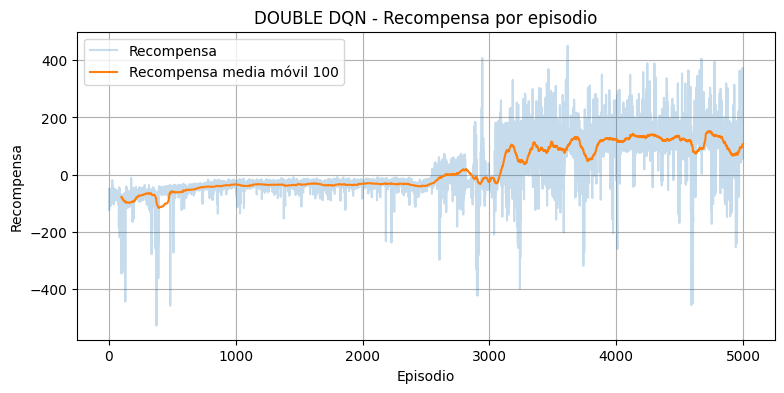

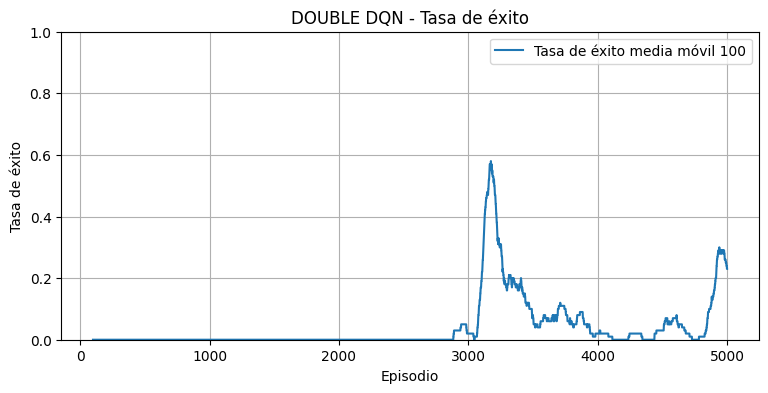

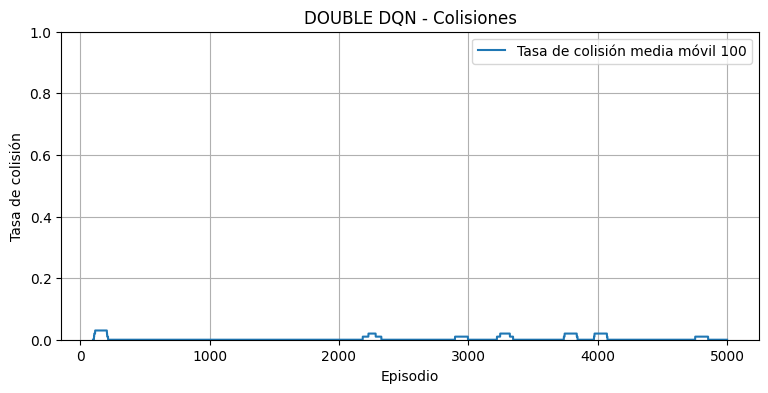

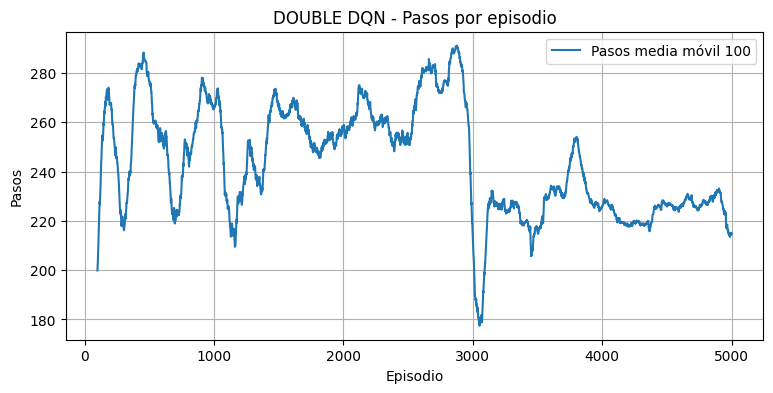

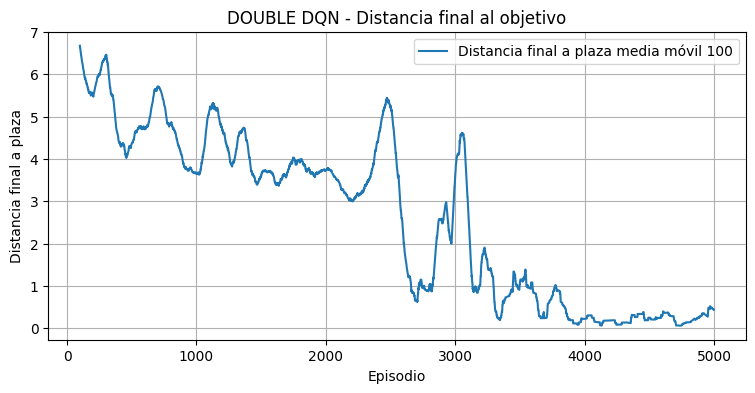

In [5]:

plot_results("double_dqn")

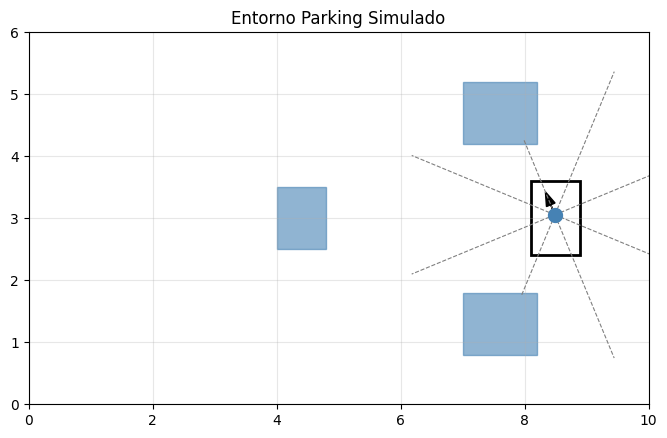

Episodio terminado en 267 pasos — ⏱ Tiempo agotado
Distancia final a la plaza: 0.057 m


In [7]:
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_double = QNetwork(n_obs=18, n_actions=7).to(device)
model_double.load_state_dict(torch.load("results/double_dqn_model.pt", map_location=device))
model_double.eval()


visualizar_agente("Double DQN", model_double)


## Conclusiones del Double DQN

El Double DQN introduce una única modificación sobre el DQN estándar: desacopla la **selección** de la acción óptima (red online, pesos θ) de la **evaluación** de su valor (red target, pesos θ⁻), sincronizando ambas redes cada 1 000 pasos de aprendizaje. El target de Bellman pasa de:

$$y = r + \gamma \cdot \max_{a'} Q(s', a'; \theta) \quad \text{[DQN]}$$

a:

$$y = r + \gamma \cdot Q\!\left(s',\, \argmax_{a'} Q(s', a'; \theta);\, \theta^-\right) \quad \text{[Double DQN]}$$

Esta modificación, aparentemente pequeña, produce una mejora sustancial: la convergencia real (>70 % de episodios a <0.35 m de la plaza) se produce en el **episodio 2 664** — casi 2 000 antes que el DQN. En los tramos finales el **89-97 %** de los episodios terminan dentro del radio de la plaza, la distancia media cae a **0.19 m** en el mejor tramo y las colisiones se reducen a un 0.2 %.

Un dato interesante es que la tasa de éxito estricta no es monótona: alcanza un pico del 31 % en torno al ep. 3 000 y luego desciende, incluso mientras la distancia media sigue mejorando. Esto no indica regresión — el agente se está posicionando cada vez más cerca, pero cumplir simultáneamente las cuatro condiciones de éxito (distancia, orientación, velocidad y frenado) requiere una precisión que la exploración residual dificulta en los episodios intermedios.

La limitación que persiste es arquitectónica: la red no distingue entre el **valor intrínseco de un estado** y la **ventaja relativa de cada acción**, tratando ambos conceptos de forma entrelazada. Esta es precisamente la innovación del **Dueling DQN**.

---

## Tabla de Hiperparámetros — Double DQN

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| Episodios | 5 000 | Convergencia real en ep. ~2 600; 5 000 son suficientes para estabilizar. 2 000 menos que el DQN. |
| Pasos máximos / episodio | 300 | Igual que el DQN. |
| Warmup steps | 5 000 | Igual que el DQN. |
| Factor de descuento γ | 0.99 | Igual que el DQN; el horizonte de planificación no cambia. |
| Tasa de aprendizaje lr | 5 × 10⁻⁴ | Igual que el DQN. |
| Tamaño de batch | 128 | Igual que el DQN. |
| Tamaño replay buffer | 60 000 | Igual que el DQN. |
| ε inicial | 1.0 | Igual que el DQN. |
| ε mínimo | 0.1 | Igual que el DQN. |
| ε decay | 0.998 | Ligeramente más rápido que el DQN (0.999): con menos episodios conviene pasar antes a explotación. |
| Sincronización red target | Cada 1 000 learn-steps | Intervalo que equilibra estabilidad (targets no obsoletos) y beneficio del desacople. |
| Frecuencia de aprendizaje | Cada 4 pasos | Igual que el DQN. |
| Arquitectura | 18 → 128 → 128 → 7 | Más ancha que el DQN (64 → 128) para capturar relaciones más sutiles al coordinar dos redes. |